<a href="https://colab.research.google.com/github/Leeloo-Kikontwe/Codveda_Technologies_Machine_Learning_Internship/blob/main/Task6/Task2_Level3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, precision_score, roc_auc_score
from sklearn.inspection import DecisionBoundaryDisplay

In [5]:
path = '/content/drive/MyDrive/Data_Set_For_Task/Data_Set_For_Task/iris.csv'
df = pd.read_csv(path)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


EDA

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [7]:
df.shape

(150, 5)

In [8]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [9]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [10]:
df.duplicated().sum()
df.drop_duplicates()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [11]:
df["species"].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


DATA VISUALISATION

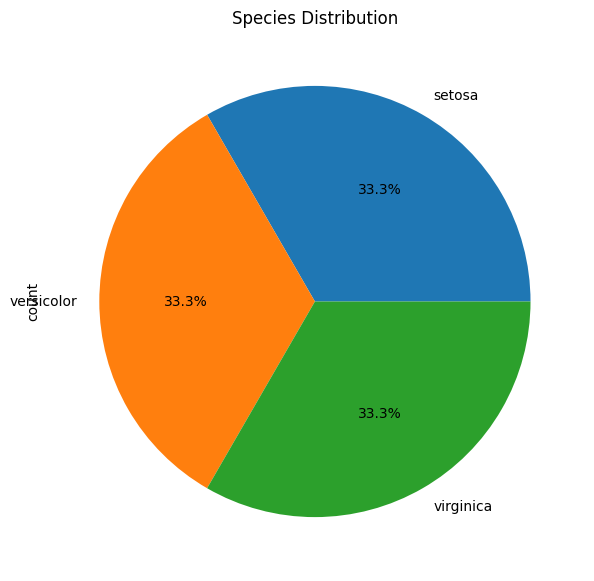

In [12]:
plt.figure(figsize = (7,7))
df['species'].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.title("Species Distribution")
plt.show()

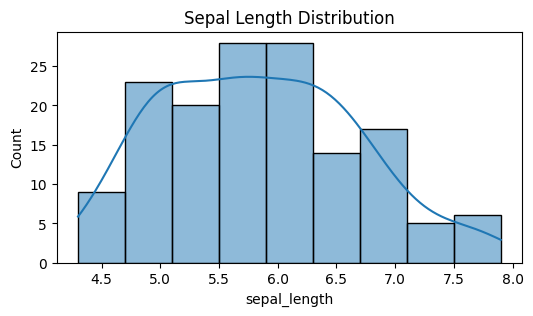

In [13]:
plt.figure(figsize=(6, 3))
sns.histplot(df['sepal_length'], kde=True)
plt.title('Sepal Length Distribution')
plt.show()

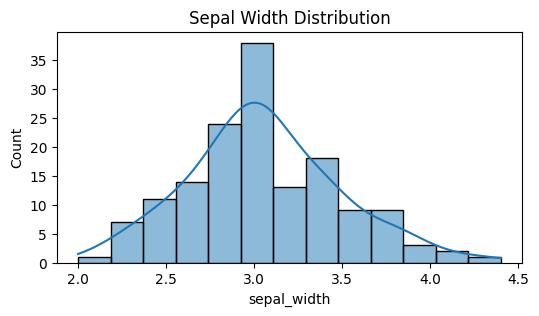

In [14]:
plt.figure(figsize=(6,3))
sns.histplot(df['sepal_width'], kde=True)
plt.title('Sepal Width Distribution')
plt.show()

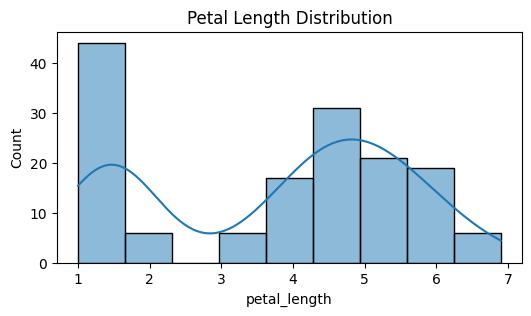

In [15]:
plt.figure(figsize=(6,3))
sns.histplot(df['petal_length'], kde=True)
plt.title('Petal Length Distribution')
plt.show()

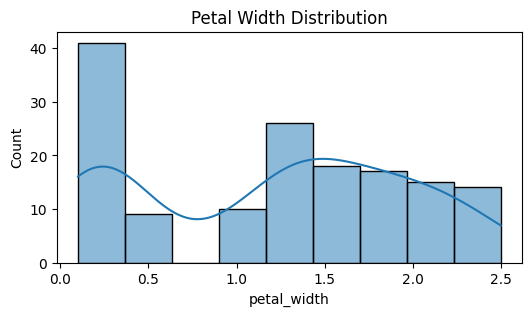

In [16]:
plt.figure(figsize=(6,3))
sns.histplot(df['petal_width'], kde=True)
plt.title('Petal Width Distribution')
plt.show()

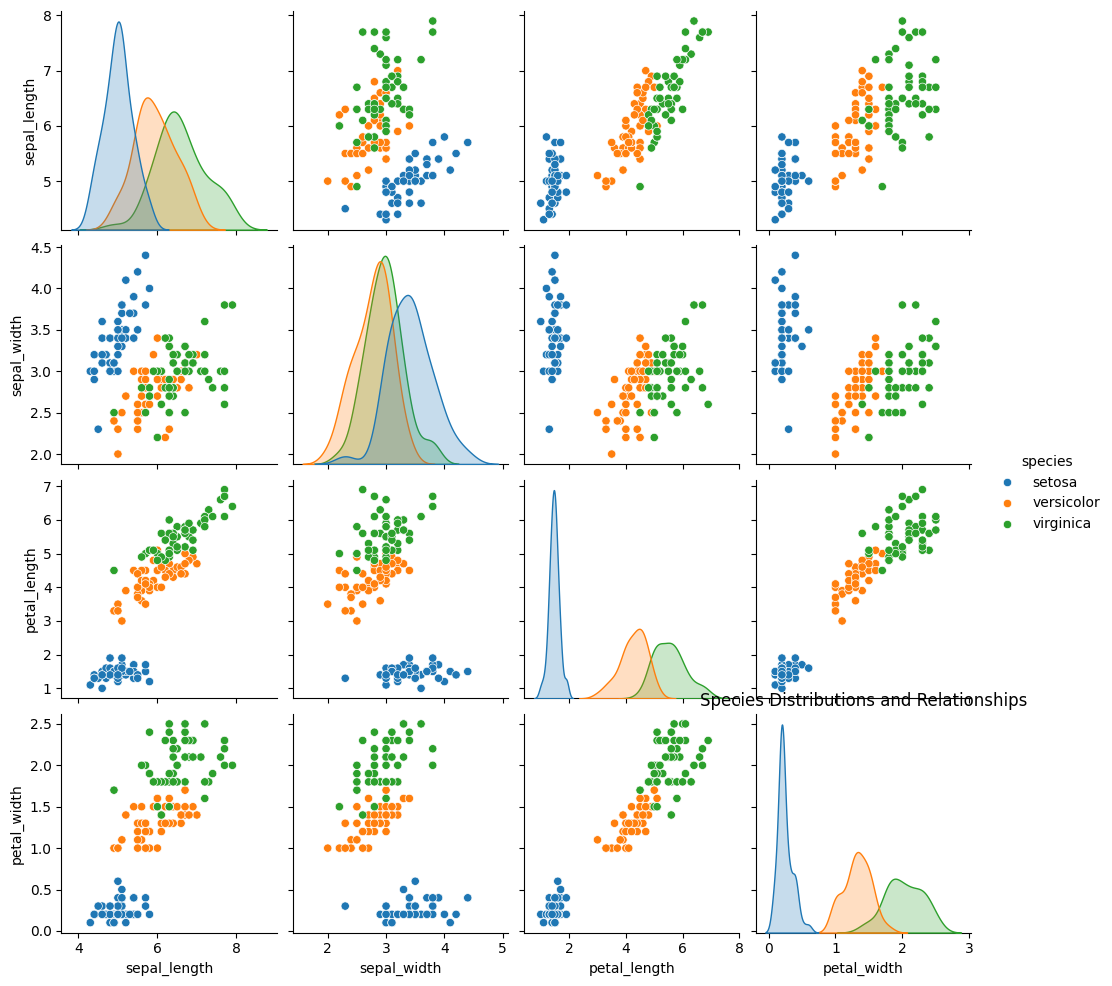

In [17]:
sns.pairplot(df, hue='species')
plt.title('Species Distributions and Relationships')
plt.show()

ENCODING THE TARGET VARIABLE

In [18]:
df['species'] = df['species'].map({'setosa': 0, 'versicolor': 1, 'virginica': 2})

In [19]:
#We keep only species
data = df[df['species'].isin([1, 2])].copy()

SEPARATE FEATURES AND TARGET

In [20]:
#We keep only 2 features
x = data[['petal_length','petal_width']]
y = data['species']

SPLIT THE DATASET INTO TRAINING AND TESTING SETS

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

FEATURE SCALING

In [22]:
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

BUILD AND TRAIN THE SVM MODEL USING LINEAR AND RBF KERNELS

In [24]:
svm_linear = SVC(kernel='linear', C=1.0, probability=True)
svm_linear.fit(x_train_scaled, y_train)


SVC(kernel='linear', probability=True)

In [26]:
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
svm_rbf.fit(x_train_scaled, y_train)

SVC(probability=True)

PREDICTIONS

In [34]:
#For the linear SVM
y_pred_linear = svm_linear.predict(x_test_scaled)
y_proba_linear = svm_linear.predict_proba(x_test_scaled)[:, 1]

In [35]:
#For the RBF SVM
y_pred_rbf = svm_rbf.predict(x_test_scaled)
y_proba_rbf = svm_rbf.predict_proba(x_test_scaled)[:, 1]

PERFORMANCE METRICS

In [38]:
#For the Linear SVM
accuracy_linear = accuracy_score(y_test, y_pred_linear)
precision_linear = precision_score(y_test, y_pred_linear)
recall_linear = recall_score(y_test, y_pred_linear)
auc_linear = roc_auc_score(y_test, y_proba_linear)

#For the RBF SVM
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
precision_rbf = precision_score(y_test, y_pred_rbf)
recall_rbf = recall_score(y_test, y_pred_rbf)
auc_rbf = roc_auc_score(y_test, y_proba_rbf)

PERFORMANCE COMPARISON

In [40]:
print("Metric  |   Linear |  RBF")
print(""*20)
print(f"Accuracy: {accuracy_linear:.3f} | {accuracy_rbf:.3f}")
print(f"Precision: {precision_linear:.3f} | {precision_rbf:.3f}")
print(f"Recall: {recall_linear:.3f} | {recall_rbf:.3f}")
print(f"AUC: {auc_linear:.3f} | {auc_rbf:.3f}")

Metric  |   Linear |  RBF

Accuracy: 0.900 | 0.900
Precision: 0.917 | 0.917
Recall: 0.917 | 0.917
AUC: 0.979 | 0.990


VISUALIZE THE DECISION BOUNDARY

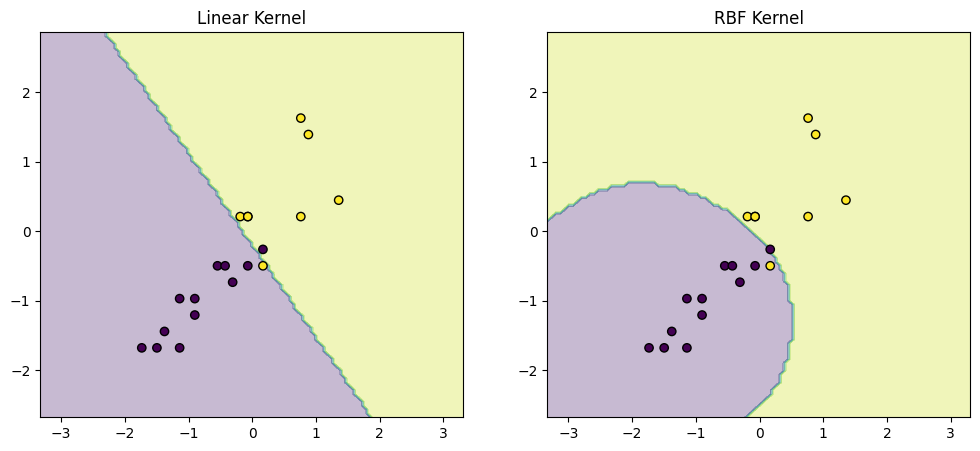

In [51]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

models = [svm_linear, svm_rbf]
titles = ['Linear Kernel', 'RBF Kernel']

for i, model in enumerate(models):
    DecisionBoundaryDisplay.from_estimator(
        model,
        x_train_scaled,
        response_method="predict",
        alpha=0.3,
        ax=ax[i]
    )
    ax[i].scatter(x_test_scaled[:, 0], x_test_scaled[:, 1], c=y_test,
                  edgecolors='k')
    ax[i].set_title(titles[i])

plt.show()
